# Outcome Estimation with T-Learner

既存のクーポン配布データを使って、`T-learner` によるアウトカム予測を行います。

各ユーザーについて観測されているのは `Y(0), Y(1)` のどちらか片方だけなので、treated 群のモデルで `\hat{Y}(1)`、control 群のモデルで `\hat{Y}(0)` を作り、未観測側を補完します。

この Notebook では次の 2 つを見ます。

- 単一実験: `n=50000`・treated 比率 `0.3` の 1 回の推定結果を詳しく見て、真の効果 `tau` と推定効果 `tau_hat` を 3D で比較する
- データ数実験: サンプルサイズを変えたときに `T-learner` の推定誤差がどう変わるかを確認する

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("/home/kohei/WorkSpace/blog/05.effectiveness/data/sampledata_coupon.parquet")
SAMPLE_SIZE = 50000
SAMPLE_SIZES = [100, 1000, 5000, 10000, 50000]
TREATED_RATIO = 0.3
RANDOM_STATE = 42


In [35]:
df = pd.read_parquet(DATA_PATH)
print(df.shape)
display(df.head())


(50000, 12)


,id,gender,age,recency,frequency,amount,tau,treatment_rate,treatment,y0,y1,outcome
0,1,m,23,7,5,11580,712,0.686658,1,11580,12292,12196
1,2,f,28,22,6,11378,1324,0.442670,1,11378,12702,12717
2,3,f,21,14,3,10087,596,0.677323,1,10087,10683,10820
3,4,f,32,10,5,12558,1304,0.227461,0,12558,13862,13480
4,5,m,35,3,4,9199,1934,0.086595,1,9199,11133,10626


## データの確認

- `gender`, `age`, `recency`, `frequency`, `amount`: 事前に観測できる特徴量
- `treatment`: 実際に介入されたかどうか
- `outcome`: 実際に観測されたアウトカム
- `tau`, `y0`, `y1`: シミュレーションなので確認できる真値

モデルにはリークを避けるため、`tau`, `y0`, `y1`, `treatment_rate`, `outcome` は特徴量に入れません。

In [36]:
summary_cols = [
    "gender",
    "age",
    "recency",
    "frequency",
    "amount",
    "treatment",
    "outcome",
    "tau",
]

display(df[summary_cols].head())
display(df[["age", "recency", "frequency", "amount", "treatment", "outcome", "tau"]].describe().T)


,gender,age,recency,frequency,amount,treatment,outcome,tau
0,m,23,7,5,11580,1,12196,712
1,f,28,22,6,11378,1,12717,1324
2,f,21,14,3,10087,1,10820,596
3,f,32,10,5,12558,0,13480,1304
4,m,35,3,4,9199,1,10626,1934


,count,mean,std,min,25%,50%,75%,max
age,50000.0,30.54422,9.089170,18.0,23.0,30.0,37.00,70.0
recency,50000.0,10.15370,5.753303,0.0,6.0,10.0,14.00,30.0
frequency,50000.0,4.98740,2.217706,0.0,3.0,5.0,6.00,19.0
amount,50000.0,11282.92428,2081.674725,1098.0,9971.0,11356.0,12685.25,19019.0
treatment,50000.0,0.30902,0.462094,0.0,0.0,0.0,1.00,1.0
outcome,50000.0,11521.02302,2157.459243,732.0,10185.0,11671.0,13013.25,19411.0
tau,50000.0,957.73788,551.994785,0.0,438.0,921.0,1428.00,2000.0


In [37]:
feature_cols = ["gender", "age", "recency", "frequency", "amount"]
categorical_features = ["gender"]
numeric_features = ["age", "recency", "frequency", "amount"]


def sample_dataset_by_size(df_input, n, treated_ratio=0.3, random_state=42):
    treated_n = int(round(n * treated_ratio))
    control_n = n - treated_n

    treated_pool = df_input[df_input["treatment"] == 1]
    control_pool = df_input[df_input["treatment"] == 0]

    treated_sample = treated_pool.sample(
        n=treated_n,
        replace=treated_n > len(treated_pool),
        random_state=random_state,
    )
    control_sample = control_pool.sample(
        n=control_n,
        replace=control_n > len(control_pool),
        random_state=random_state + 1,
    )

    sample_df = pd.concat([treated_sample, control_sample], axis=0)
    sample_df = sample_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return sample_df


def make_regression_pipeline(random_state=42):
    preprocess = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features,
            ),
            ("num", "passthrough", numeric_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "model",
                XGBRegressor(
                    n_estimators=300,
                    max_depth=4,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    eval_metric="mae",
                    random_state=random_state,
                ),
            ),
        ]
    )


def evaluate_t_learner(df_input, random_state=42):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    oof_y0_hat = np.zeros(len(df_input))
    oof_y1_hat = np.zeros(len(df_input))

    X_all = df_input[feature_cols].copy()
    treatment_all = df_input["treatment"].copy()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_all, treatment_all), start=1):
        train_df = df_input.iloc[train_idx].copy()
        valid_X = df_input.iloc[valid_idx][feature_cols].copy()

        train_treated = train_df[train_df["treatment"] == 1]
        train_control = train_df[train_df["treatment"] == 0]

        y1_model = make_regression_pipeline(random_state=random_state + fold)
        y0_model = make_regression_pipeline(random_state=random_state + 100 + fold)

        y1_model.fit(train_treated[feature_cols], train_treated["outcome"])
        y0_model.fit(train_control[feature_cols], train_control["outcome"])

        oof_y1_hat[valid_idx] = y1_model.predict(valid_X)
        oof_y0_hat[valid_idx] = y0_model.predict(valid_X)

    df_outcome = df_input.copy()
    df_outcome["y0_hat"] = oof_y0_hat
    df_outcome["y1_hat"] = oof_y1_hat
    df_outcome["tau_hat"] = df_outcome["y1_hat"] - df_outcome["y0_hat"]
    df_outcome["tau_error"] = df_outcome["tau_hat"] - df_outcome["tau"]

    df_outcome["observed_potential_outcome"] = np.where(
        df_outcome["treatment"] == 1,
        df_outcome["y1"],
        df_outcome["y0"],
    )
    df_outcome["counterfactual_true"] = np.where(
        df_outcome["treatment"] == 1,
        df_outcome["y0"],
        df_outcome["y1"],
    )
    df_outcome["observed_side_hat"] = np.where(
        df_outcome["treatment"] == 1,
        df_outcome["y1_hat"],
        df_outcome["y0_hat"],
    )
    df_outcome["counterfactual_hat"] = np.where(
        df_outcome["treatment"] == 1,
        df_outcome["y0_hat"],
        df_outcome["y1_hat"],
    )

    metrics = {
        "sample_size": len(df_outcome),
        "treated_ratio": df_outcome["treatment"].mean(),
        "y0_mae": mean_absolute_error(df_outcome["y0"], df_outcome["y0_hat"]),
        "y1_mae": mean_absolute_error(df_outcome["y1"], df_outcome["y1_hat"]),
        "factual_mae": mean_absolute_error(df_outcome["observed_potential_outcome"], df_outcome["observed_side_hat"]),
        "counterfactual_mae": mean_absolute_error(df_outcome["counterfactual_true"], df_outcome["counterfactual_hat"]),
        "tau_mae": mean_absolute_error(df_outcome["tau"], df_outcome["tau_hat"]),
        "true_ate": df_outcome["tau"].mean(),
        "estimated_ate": df_outcome["tau_hat"].mean(),
    }
    metrics["ate_abs_error"] = abs(metrics["true_ate"] - metrics["estimated_ate"])

    return df_outcome, metrics


## 単一実験

まずは `n=50000` の単一サンプルで `T-learner` を 1 回実行し、指標と効果の形を確認します。

In [38]:
experiment_df = sample_dataset_by_size(
    df,
    n=SAMPLE_SIZE,
    treated_ratio=TREATED_RATIO,
    random_state=RANDOM_STATE,
)

display(
    pd.DataFrame(
        {
            "rows": [len(experiment_df)],
            "treated_ratio": [experiment_df["treatment"].mean()],
            "treated_count": [int(experiment_df["treatment"].sum())],
            "control_count": [int((1 - experiment_df["treatment"]).sum())],
        }
    )
)

result_df, metrics = evaluate_t_learner(experiment_df, random_state=RANDOM_STATE)
metrics_df = pd.DataFrame([metrics])
display(metrics_df.round(3))


,rows,treated_ratio,treated_count,control_count
0,50000,0.3,15000,35000


,sample_size,treated_ratio,y0_mae,y1_mae,factual_mae,counterfactual_mae,tau_mae,true_ate,estimated_ate,ate_abs_error
0,50000,0.3,54.768,96.273,56.329,94.711,108.441,960.308,975.191,14.884


## 真の効果と推定効果の 3D 比較

生成時の可視化と揃えるため、横軸を `age`、奥行き軸を `amount` に固定します。左は単一実験サンプル `result_df` に含まれる真の効果 `tau`、右は同じサンプルに対する `T-learner` の推定効果 `tau_hat` です。どちらも全データを使って描画します。

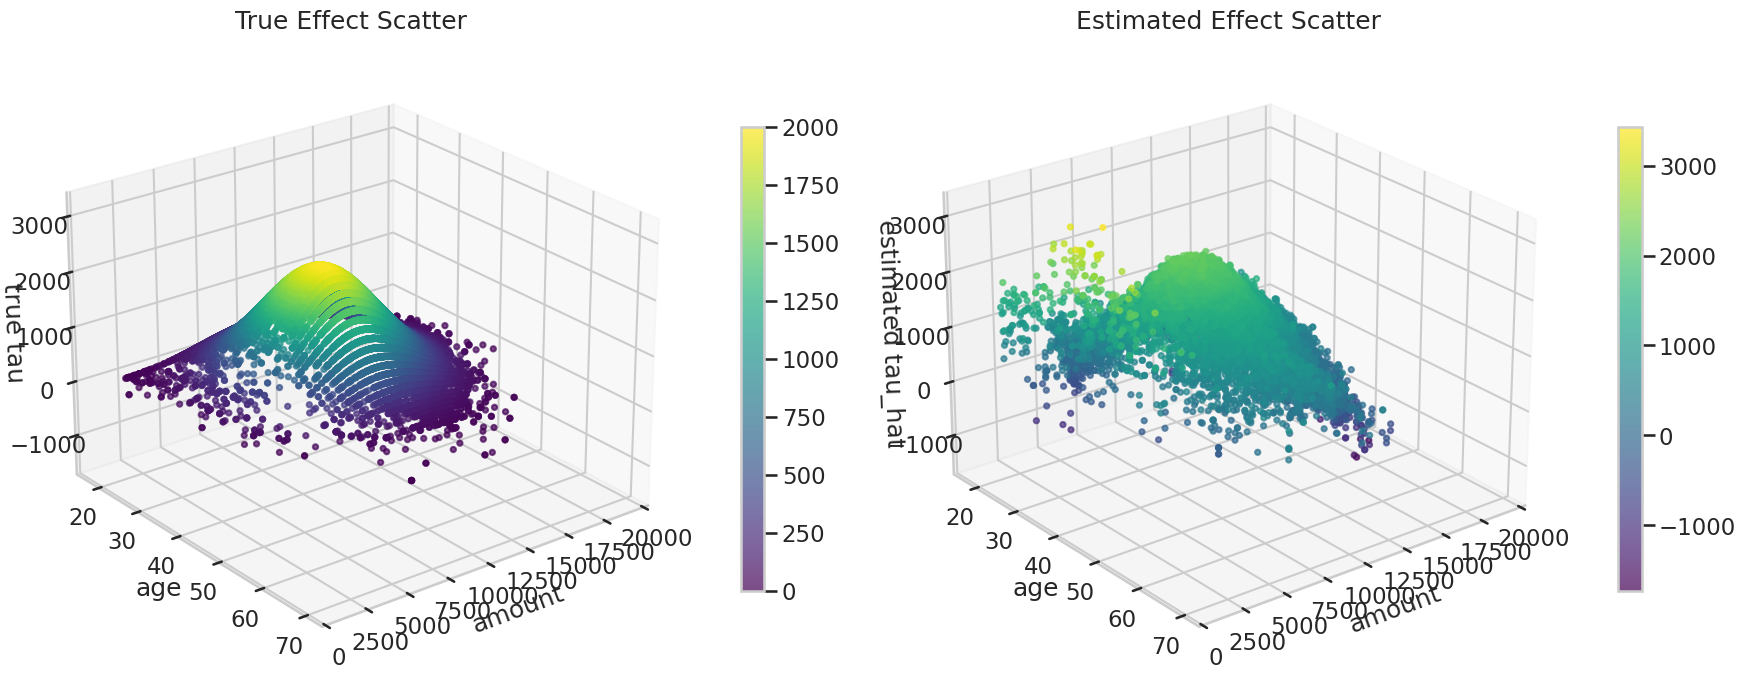

,true_ate,estimated_ate,tau_mae,plot_sample_n
0,960.308,975.191,108.441,50000


In [39]:
plot_cols = ["amount", "age", "tau", "tau_hat"]
plot_sample_n = len(result_df)
plot_df = result_df[plot_cols].copy()

z_min = min(plot_df["tau"].min(), plot_df["tau_hat"].min())
z_max = max(plot_df["tau"].max(), plot_df["tau_hat"].max())

fig = plt.figure(figsize=(18, 7))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

sc1 = ax1.scatter(
    plot_df["amount"],
    plot_df["age"],
    plot_df["tau"],
    c=plot_df["tau"],
    cmap="viridis",
    s=14,
    alpha=0.7,
)

sc2 = ax2.scatter(
    plot_df["amount"],
    plot_df["age"],
    plot_df["tau_hat"],
    c=plot_df["tau_hat"],
    cmap="viridis",
    s=14,
    alpha=0.7,
)

for ax, title, z_label in [
    (ax1, "True Effect Scatter", "true tau"),
    (ax2, "Estimated Effect Scatter", "estimated tau_hat"),
]:
    ax.set_title(title)
    ax.set_xlabel("amount")
    ax.set_ylabel("age")
    ax.set_zlabel(z_label)
    ax.set_zlim(z_min, z_max)
    ax.invert_yaxis()
    ax.view_init(elev=24, azim=-128)

fig.colorbar(sc1, ax=ax1, shrink=0.72, pad=0.08)
fig.colorbar(sc2, ax=ax2, shrink=0.72, pad=0.08)
plt.tight_layout()
plt.show()

compare_df = pd.DataFrame(
    {
        "true_ate": [result_df["tau"].mean()],
        "estimated_ate": [result_df["tau_hat"].mean()],
        "tau_mae": [mean_absolute_error(result_df["tau"], result_df["tau_hat"])],
        "plot_sample_n": [plot_sample_n],
    }
)
display(compare_df.round(3))


## データ数実験

次に、treated 比率を `0.3` に固定したままサンプルサイズを変え、推定誤差がどう変わるかを見ます。

,sample_size,treated_ratio,y0_mae,y1_mae,factual_mae,counterfactual_mae,tau_mae,true_ate,estimated_ate,ate_abs_error
0,100,0.3,369.637,497.580,385.468,481.750,484.246,969.770,909.418,60.352
1,1000,0.3,218.327,345.144,230.898,332.573,376.213,983.784,1099.257,115.473
2,5000,0.3,109.332,227.398,123.021,213.709,248.921,958.215,1068.567,110.353
3,10000,0.3,92.374,164.008,98.086,158.296,181.467,955.948,967.108,11.161
4,50000,0.3,59.942,95.446,59.956,95.432,111.136,961.062,984.524,23.462


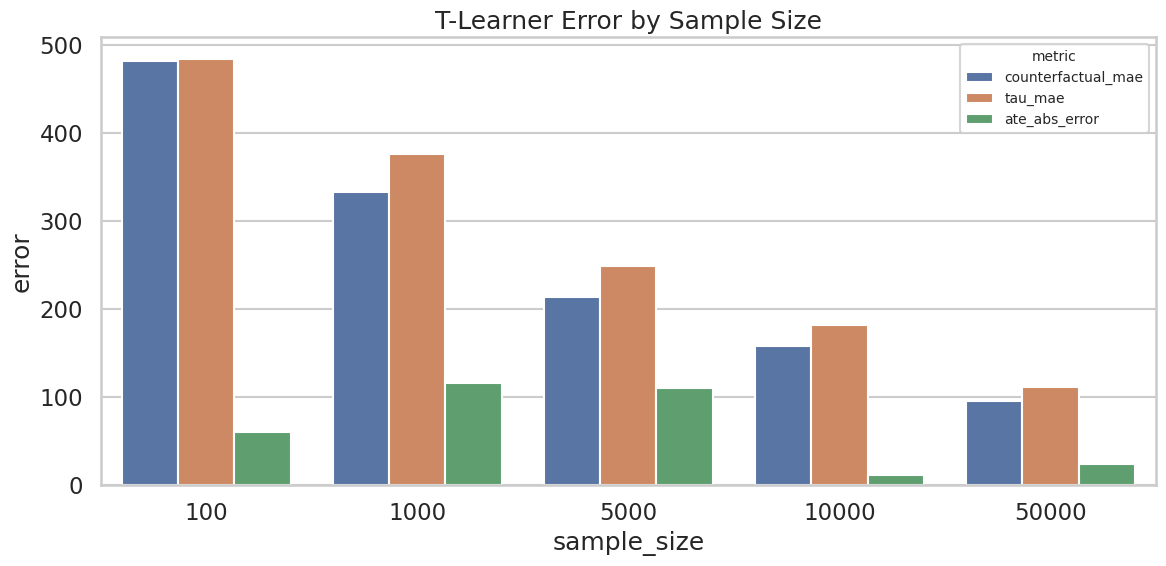

In [40]:
sample_size_records = []

for i, sample_size in enumerate(SAMPLE_SIZES):
    sampled_df = sample_dataset_by_size(
        df,
        n=sample_size,
        treated_ratio=TREATED_RATIO,
        random_state=RANDOM_STATE + i,
    )
    _, sample_metrics = evaluate_t_learner(sampled_df, random_state=RANDOM_STATE + 100 + i)
    sample_size_records.append(sample_metrics)

sample_size_metrics_df = pd.DataFrame(sample_size_records).sort_values("sample_size").reset_index(drop=True)
display(sample_size_metrics_df.round(3))

sample_size_plot_df = sample_size_metrics_df.melt(
    id_vars=["sample_size", "treated_ratio"],
    value_vars=["counterfactual_mae", "tau_mae", "ate_abs_error"],
    var_name="metric",
    value_name="value",
)
sample_size_plot_df["sample_size"] = sample_size_plot_df["sample_size"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=sample_size_plot_df,
    x="sample_size",
    y="value",
    hue="metric",
)
plt.title("T-Learner Error by Sample Size")
plt.xlabel("sample_size")
plt.ylabel("error")
plt.legend(title="metric", fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()


## 観察

- 単一実験では、`n=50000` のときに `tau_mae` と `ATE` のズレがどの程度か、また真値と推定値の点群の位置関係を確認できます。
- 3D 散布図では、`amount` と `age` に対して効果がどのあたりに分布しているかを、真値と推定値で素直に見比べられます。
- データ数実験では、一般にサンプルサイズが大きくなるにつれて `counterfactual_mae` や `tau_mae` が下がるかを確認できます。
- 単一実験の詳細図と、データ数実験の全体傾向を並べることで、1 回の推定結果とサンプルサイズ依存の両方を読みやすくしています。